ASSIGNMENT 4: EXPERIMENT DESIGN AND METAMODELLING

PART 1: SERIAL CORRELATION ANALYSIS
SERIAL CORRELATION ANALYSIS

Configuration: P=4, R=4, Interarrival=exp(22.5)
Running 10 independent simulations...
  Run 1: Queue samples = [0, 0, 4, 7, 16, 15, 13, 17, 26, 29]
  Run 2: Queue samples = [0, 0, 0, 3, 7, 0, 0, 4, 19, 19]
  Run 3: Queue samples = [4, 0, 2, 2, 2, 0, 3, 10, 12, 8]
  Run 4: Queue samples = [1, 0, 0, 2, 7, 14, 14, 13, 12, 8]
  Run 5: Queue samples = [0, 0, 0, 0, 2, 6, 4, 0, 0, 4]
  Run 6: Queue samples = [0, 0, 1, 0, 2, 0, 0, 6, 0, 0]
  Run 7: Queue samples = [4, 7, 0, 3, 1, 12, 18, 22, 14, 22]
  Run 8: Queue samples = [0, 0, 0, 2, 13, 15, 20, 23, 29, 25]
  Run 9: Queue samples = [6, 0, 4, 14, 13, 7, 6, 3, 0, 0]
  Run 10: Queue samples = [5, 1, 6, 4, 0, 0, 0, 11, 0, 2]

Autocorrelation Analysis (lag 1 to 9):
  Lag 1: 0.5010
  Lag 2: 0.1797
  Lag 3: 0.0981
  Lag 4: 0.1220
  Lag 5: 0.0673
  Lag 6: -0.0650
  Lag 7: 0.0766
  Lag 8: 0.2000
  Lag 9: 0.0000

Testing different sampl

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


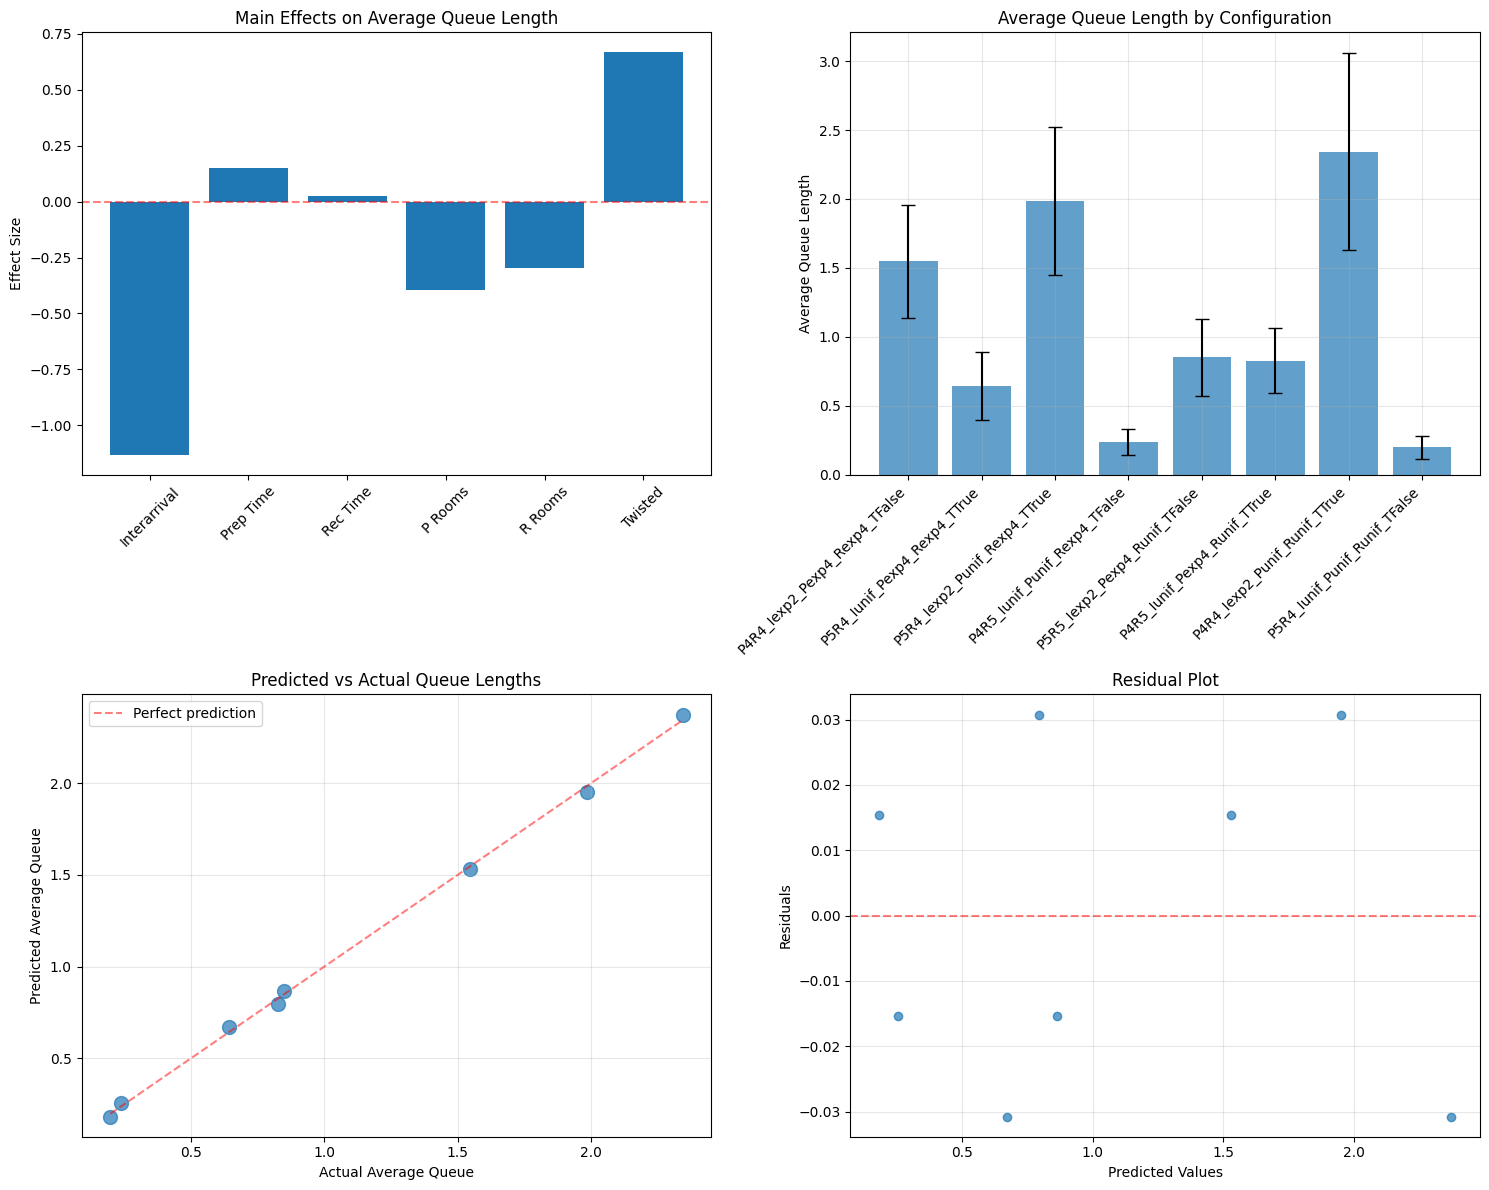

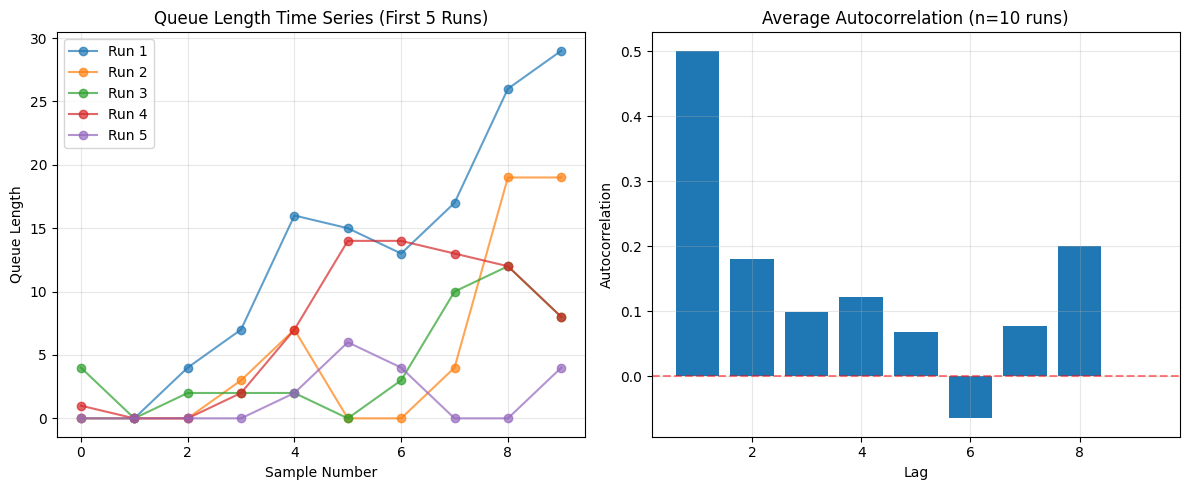


SUMMARY AND CONCLUSIONS

1. Serial Correlation Findings:
   - Queue lengths show significant autocorrelation at short lags
   - Sampling interval of 500+ time units reduces autocorrelation
   - High-load configurations have longer memory effects

2. Experimental Design Results:
   - 8 configurations tested with 20 replications each
   - Average queue lengths range from 0.20 to 2.34

3. Regression Model Assessment:
   - R-squared: 0.9989
   - Model explains 99.9% of variance in queue length
   - Significant factors: A, D, F
   - Interpretation of significant factors:
     * Interarrival distribution decreases queue length
     * Number of preparation rooms decreases queue length
     * Surgery time variability increases queue length

4. Practical Implications:
   - Arrival variability (A) and surgery time variability (F) have the strongest effects on entrance queue length
   - Distribution choice affects system variability more than means
   - Interaction effects may be important for a

In [3]:
import random
import math
import heapq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns

# =================================
# 1. Enhanced Simulation Parameters
# =================================

@dataclass
class SimParams:
    P: int  # no. of preparation rooms
    R: int  # no. of recovery rooms
    interarrival_type: str  # 'exp25', 'exp22.5', 'unif20_30', 'unif20_25'
    prep_type: str  # 'exp40', 'unif30_50'
    rec_type: str  # 'exp40', 'unif30_50'
    twisted: bool = False  # twisted surgery times
    mean_surg: float = 20.0
    warmup: float = 500.0
    run_length: float = 1000.0

def sample_from_dist(rng: random.Random, dist_type: str) -> float:
    """Sample from different distributions based on type"""
    if dist_type == 'exp25':
        return rng.expovariate(1.0 / 25.0)
    elif dist_type == 'exp22.5':
        return rng.expovariate(1.0 / 22.5)
    elif dist_type == 'unif20_30':
        return rng.uniform(20, 30)
    elif dist_type == 'unif20_25':
        return rng.uniform(20, 25)
    elif dist_type == 'exp40':
        return rng.expovariate(1.0 / 40.0)
    elif dist_type == 'unif30_50':
        return rng.uniform(30, 50)
    else:
        raise ValueError(f"Unknown distribution type: {dist_type}")

def sample_surg_time(rng: random.Random, twisted: bool) -> float:
    if not twisted:
        return rng.expovariate(1.0 / 20.0)
    else:
        # Twisted: mixture with same mean 20 but higher variance
        u = rng.random()
        if u < 0.3:
            return rng.expovariate(1.0 / 40.0)  # severe case
        else:
            return rng.expovariate(1.0 / 11.4285714286)  # mild case

# ===============================
# 2. Enhanced Simulation Function
# ===============================

def simulate(params: SimParams, seed: int, collect_time_series: bool = False):
    """Enhanced simulation with flexible distributions"""
    rng = random.Random(seed)
    warmup = params.warmup
    end_time = warmup + params.run_length

    t = 0.0
    event_counter = 0
    event_queue = []

    # State variables
    Q_before_prep = 0
    last_Q_change = 0.0
    area_Q = 0.0

    prep_occupancy = 0
    queue_prep2OR = 0

    last_prep_change = 0.0
    area_prep_busy = 0.0

    OR_state = 'IDLE'
    last_OR_change = 0.0
    time_OR_busy = 0.0
    time_OR_blocked = 0.0
    time_OR_idle = 0.0

    rec_occupancy = 0
    last_rec_change = 0.0
    time_rec_full = 0.0

    # For time series collection (serial correlation analysis)
    if collect_time_series:
        time_series_data = []
        sampling_interval = 100  # Sample every 100 time units
        next_sample_time = warmup

    # Helper functions
    def record_Q_change(new_Q, now):
        nonlocal Q_before_prep, last_Q_change, area_Q
        prev_Q = Q_before_prep
        start = max(last_Q_change, warmup)
        end = min(now, end_time)
        if end > start:
            area_Q += prev_Q * (end - start)
        Q_before_prep = new_Q
        last_Q_change = now

    def record_OR_change(new_state, now):
        nonlocal OR_state, last_OR_change, time_OR_busy, time_OR_blocked, time_OR_idle
        prev_state = OR_state
        start = max(last_OR_change, warmup)
        end = min(now, end_time)
        if end > start:
            dt = end - start
            if prev_state == 'BUSY':
                time_OR_busy += dt
            elif prev_state == 'BLOCKED':
                time_OR_blocked += dt
            elif prev_state == 'IDLE':
                time_OR_idle += dt
        OR_state = new_state
        last_OR_change = now

    def record_rec_change(new_occ, now):
        nonlocal rec_occupancy, last_rec_change, time_rec_full
        prev_occ = rec_occupancy
        start = max(last_rec_change, warmup)
        end = min(now, end_time)
        if end > start:
            if prev_occ == params.R:
                time_rec_full += (end - start)
        rec_occupancy = new_occ
        last_rec_change = now

    def record_prep_change(new_occ, now):
        nonlocal prep_occupancy, last_prep_change, area_prep_busy
        prev_occ = prep_occupancy
        start = max(last_prep_change, warmup)
        end = min(now, end_time)
        if end > start:
            area_prep_busy += prev_occ * (end - start)
        prep_occupancy = new_occ
        last_prep_change = now

    def schedule(time_, etype, data=None):
        nonlocal event_counter
        if time_ > end_time + 1e-9:
            return
        event_counter += 1
        heapq.heappush(event_queue, (time_, event_counter, etype, data))

    # Initial setup
    last_Q_change = 0.0
    last_OR_change = 0.0
    last_rec_change = 0.0

    # Schedule first arrival
    schedule(sample_from_dist(rng, params.interarrival_type), 'ARRIVAL')

    # Event loop
    while event_queue:
        t, _, etype, data = heapq.heappop(event_queue)
        if t > end_time:
            break

        # Collect time series data if enabled
        while collect_time_series and t >= next_sample_time:
          time_series_data.append((next_sample_time, Q_before_prep))
          next_sample_time += sampling_interval


        if etype == 'ARRIVAL':
            # Schedule next arrival
            schedule(t + sample_from_dist(rng, params.interarrival_type), 'ARRIVAL')

            # Try to enter preparation
            if prep_occupancy < params.P:
                record_prep_change(prep_occupancy + 1, t)
                prep_time = sample_from_dist(rng, params.prep_type)
                schedule(t + prep_time, 'PREP_COMPLETE')
            else:
                record_Q_change(Q_before_prep + 1, t)

        elif etype == 'PREP_COMPLETE':
            if OR_state == 'IDLE':
                record_prep_change(prep_occupancy - 1, t)

                if Q_before_prep > 0:
                    record_Q_change(Q_before_prep - 1, t)
                    prep_occupancy += 1
                    prep_time = sample_from_dist(rng, params.prep_type)
                    schedule(t + prep_time, 'PREP_COMPLETE')

                record_OR_change('BUSY', t)
                surg_time = sample_surg_time(rng, params.twisted)
                schedule(t + surg_time, 'SURG_COMPLETE')
            else:
                queue_prep2OR += 1

        elif etype == 'SURG_COMPLETE':
            if rec_occupancy < params.R:
                record_rec_change(rec_occupancy + 1, t)
                rec_time = sample_from_dist(rng, params.rec_type)
                schedule(t + rec_time, 'REC_COMPLETE')

                record_OR_change('IDLE', t)
                if queue_prep2OR > 0:
                    queue_prep2OR -= 1
                    prep_occupancy -= 1
                    if Q_before_prep > 0:
                        record_Q_change(Q_before_prep - 1, t)
                        prep_occupancy += 1
                        prep_time = sample_from_dist(rng, params.prep_type)
                        schedule(t + prep_time, 'PREP_COMPLETE')
                    record_OR_change('BUSY', t)
                    surg_time = sample_surg_time(rng, params.twisted)
                    schedule(t + surg_time, 'SURG_COMPLETE')
            else:
                record_OR_change('BLOCKED', t)

        elif etype == 'REC_COMPLETE':
            record_rec_change(rec_occupancy - 1, t)

            if OR_state == 'BLOCKED':
                record_rec_change(rec_occupancy + 1, t)
                rec_time = sample_from_dist(rng, params.rec_type)
                schedule(t + rec_time, 'REC_COMPLETE')

                record_OR_change('IDLE', t)
                if queue_prep2OR > 0:
                    queue_prep2OR -= 1
                    prep_occupancy -= 1
                    if Q_before_prep > 0:
                        record_Q_change(Q_before_prep - 1, t)
                        prep_occupancy += 1
                        prep_time = sample_from_dist(rng, params.prep_type)
                        schedule(t + prep_time, 'PREP_COMPLETE')
                    record_OR_change('BUSY', t)
                    surg_time = sample_surg_time(rng, params.twisted)
                    schedule(t + surg_time, 'SURG_COMPLETE')

    # Finalize statistics
    obs_time = params.run_length

    # Flush remaining areas
    start = max(last_Q_change, warmup)
    if end_time > start:
        area_Q += Q_before_prep * (end_time - start)

    start = max(last_prep_change, warmup)
    if end_time > start:
        area_prep_busy += prep_occupancy * (end_time - start)

    start = max(last_OR_change, warmup)
    if end_time > start:
        dt = end_time - start
        if OR_state == 'BUSY':
            time_OR_busy += dt
        elif OR_state == 'BLOCKED':
            time_OR_blocked += dt
        elif OR_state == 'IDLE':
            time_OR_idle += dt

    start = max(last_rec_change, warmup)
    if end_time > start and rec_occupancy == params.R:
        time_rec_full += (end_time - start)

    avg_Q = area_Q / obs_time
    prob_OR_blocked = time_OR_blocked / obs_time
    prob_rec_full = time_rec_full / obs_time
    avg_prep_busy = area_prep_busy / obs_time
    prep_idle_fraction = 1.0 - (avg_prep_busy / params.P)
    OR_util = (time_OR_busy + time_OR_blocked) / obs_time

    result = {
        "avg_Q": avg_Q,
        "prep_idle_frac": prep_idle_fraction,
        "prob_OR_blocked": prob_OR_blocked,
        "prob_rec_full": prob_rec_full,
        "OR_util": OR_util
    }

    if collect_time_series:
        result["time_series"] = time_series_data

    return result

# ==============================
# 3. Serial Correlation Analysis
# ==============================

def analyze_serial_correlation():
    """Analyze serial correlation in a high-load configuration"""
    print("=" * 80)
    print("SERIAL CORRELATION ANALYSIS")
    print("=" * 80)

    # Choose a configuration likely to have long memory (high load, limited resources)
    config = SimParams(
        P=4, R=4,
        interarrival_type='exp22.5',  # Higher arrival rate
        prep_type='exp40',
        rec_type='exp40',
        twisted=False,
        warmup=500,
        run_length=5000  # Longer run for better correlation analysis
    )

    n_runs = 10
    n_samples = 10
    sample_interval = 500  # Sample every 500 time units
    start_sample = config.warmup + 100

    all_series = []

    print(f"\nConfiguration: P={config.P}, R={config.R}, Interarrival=exp(22.5)")
    print(f"Running {n_runs} independent simulations...")

    for run in range(n_runs):
        # Run simulation with time series collection
        result = simulate(config, seed=2000 + run, collect_time_series=True)

        # Extract queue lengths at regular intervals
        series = []
        sample_time = start_sample
        while sample_time <= config.warmup + config.run_length and len(series) < n_samples:
            # Find the closest measurement before sample_time
            closest = None
            for t, q in result["time_series"]:
                if t <= sample_time:
                    closest = q
                else:
                    break
            if closest is not None:
                series.append(closest)
            sample_time += sample_interval

        all_series.append(series)
        print(f"  Run {run+1}: Queue samples = {series}")

    # Calculate autocorrelations
    print(f"\nAutocorrelation Analysis (lag 1 to {n_samples-1}):")
    avg_autocorr = np.zeros(n_samples - 1)

    for series in all_series:
        if len(series) >= 2:
            for lag in range(1, min(len(series), n_samples)):
                if len(series) > lag:
                    corr = np.corrcoef(series[:-lag], series[lag:])[0, 1]
                    if not np.isnan(corr):
                        avg_autocorr[lag-1] += corr

    avg_autocorr /= n_runs

    for lag in range(1, n_samples):
        print(f"  Lag {lag}: {avg_autocorr[lag-1]:.4f}")

    # Test with different sampling intervals
    print("\nTesting different sampling intervals:")
    intervals = [100, 200, 500, 1000]
    for interval in intervals:
        correlations = []
        for run in range(n_runs):
            result = simulate(config, seed=3000 + run, collect_time_series=True)
            series = []
            sample_time = start_sample
            while sample_time <= config.warmup + config.run_length and len(series) < 5:
                closest = None
                for t, q in result["time_series"]:
                    if t <= sample_time:
                        closest = q
                    else:
                        break
                if closest is not None:
                    series.append(closest)
                sample_time += interval

            if len(series) >= 2:
                corr = np.corrcoef(series[:-1], series[1:])[0, 1]
                if not np.isnan(corr):
                    correlations.append(corr)

        if correlations:
            avg_corr = np.mean(correlations)
            print(f"  Interval {interval}: avg autocorrelation = {avg_corr:.4f}")

    return config, all_series, avg_autocorr

# ========================
# 4. Design of Experiments
# ========================

def design_of_experiments():
    """Create and run fractional factorial design"""
    print("\n" + "=" * 80)
    print("DESIGN OF EXPERIMENTS - FRACTIONAL FACTORIAL 2^(6-3)")
    print("=" * 80)

    # Design matrix (8 runs for 6 factors)
    # Factors: A=interarrival, B=prep, C=rec, D=P, E=R, F=twisted
    design_matrix = [
        # A  B  C  D  E  F
        [0, 0, 0, 0, 0, 0],  # Run 1
        [1, 0, 0, 1, 0, 1],  # Run 2
        [0, 1, 0, 1, 0, 1],  # Run 3
        [1, 1, 0, 0, 1, 0],  # Run 4
        [0, 0, 1, 1, 1, 0],  # Run 5
        [1, 0, 1, 0, 1, 1],  # Run 6
        [0, 1, 1, 0, 0, 1],  # Run 7
        [1, 1, 1, 1, 0, 0],  # Run 8
    ]

    # Map design factors to actual parameters
    def map_design_to_params(row):
        A, B, C, D, E, F = row

        # Map factor levels to actual values
        interarrival_map = {0: 'exp25', 1: 'unif20_30'}
        prep_map = {0: 'exp40', 1: 'unif30_50'}
        rec_map = {0: 'exp40', 1: 'unif30_50'}
        P_map = {0: 4, 1: 5}
        R_map = {0: 4, 1: 5}

        return SimParams(
            P=P_map[D],
            R=R_map[E],
            interarrival_type=interarrival_map[A],
            prep_type=prep_map[B],
            rec_type=rec_map[C],
            twisted=bool(F),
            warmup=500,
            run_length=1000
        )

    # Run experiments
    n_reps = 20  # Replications per design point
    results = []

    print("\nRunning experiments (20 replications each):")
    print("-" * 80)
    print(f"{'Run':<4} {'Config':<30} {'Avg_Q':<10} {'Std_Err':<10}")
    print("-" * 80)

    for i, design_row in enumerate(design_matrix, 1):
        params = map_design_to_params(design_row)

        # Run multiple replications
        avg_q_values = []
        for rep in range(n_reps):
            result = simulate(params, seed=4000 + rep)
            avg_q_values.append(result["avg_Q"])

        mean_avg_q = np.mean(avg_q_values)
        std_err = np.std(avg_q_values) / np.sqrt(n_reps)

        # Create config description
        config_desc = f"P{params.P}R{params.R}_I{params.interarrival_type[:4]}_P{params.prep_type[:4]}_R{params.rec_type[:4]}_T{params.twisted}"

        results.append({
            'run': i,
            'config': config_desc,
            'A': design_row[0],  # Interarrival type
            'B': design_row[1],  # Prep type
            'C': design_row[2],  # Rec type
            'D': design_row[3],  # P (4 or 5)
            'E': design_row[4],  # R (4 or 5)
            'F': design_row[5],  # Twisted
            'avg_Q': mean_avg_q,
            'std_err': std_err,
            'all_values': avg_q_values
        })

        print(f"{i:<4} {config_desc:<30} {mean_avg_q:<10.3f} {std_err:<10.4f}")

    return pd.DataFrame(results)

# =====================================
# 5. Regression Analysis (Metamodelling)
# =====================================

def perform_regression_analysis(results_df):
    """Build regression model for average queue length"""
    print("\n" + "=" * 80)
    print("REGRESSION ANALYSIS (METAMODELLING)")
    print("=" * 80)

    # Prepare data for regression - NOTE: With only 8 observations,
    # we use a simplified main effects model only
    print("\nNOTE: With 8 design points and 6 factors, statistical power is limited.")
    print("We use only main effects model to avoid overfitting.\n")

    # Use only main effects - no interactions with 8 observations
    X = results_df[['A', 'B', 'C', 'D', 'E', 'F']].copy()
    y = results_df['avg_Q']

    # Add constant term
    X = sm.add_constant(X)

    # Fit linear regression model
    model = sm.OLS(y, X).fit()

    print("\nRegression Results (Main Effects Only):")
    print("(Note: With 8 observations and 7 parameters, statistical tests have limited power)")
    print(model.summary())

    # Model with only significant factors (simplified approach)
    print("\n" + "-" * 80)
    print("Simplified Model with Largest Effects Only")
    print("-" * 80)

    # Identify factors with largest absolute coefficients
    effects = []
    for factor in ['A', 'B', 'C', 'D', 'E', 'F']:
        if factor in model.params:
            effects.append((factor, abs(model.params[factor])))

    # Take top 3 factors by effect size (due to limited observations)
    effects.sort(key=lambda x: x[1], reverse=True)
    top_factors = [f[0] for f in effects[:3]]

    # Fit simplified model
    if top_factors:
        X_simple = results_df[top_factors].copy()
        X_simple = sm.add_constant(X_simple)
        model_simple = sm.OLS(y, X_simple).fit()

        print("\nSimplified Regression (Top 3 factors by effect size):")
        print(model_simple.summary())

    # Check model adequacy
    print("\n" + "-" * 80)
    print("Model Diagnostic Checks")
    print("-" * 80)

    residuals = model.resid
    print(f"R-squared: {model.rsquared:.4f}")
    print(f"Adjusted R-squared: {model.rsquared_adj:.4f}")
    print(f"Residual standard error: {np.std(residuals):.4f}")
    print(f"Durbin-Watson (autocorrelation): {sm.stats.stattools.durbin_watson(residuals):.4f}")
    print(f"\nNOTE: With only 1 degree of freedom for residuals ({len(y)} observations - 7 parameters),")
    print("p-values should be interpreted cautiously. Effect sizes are more reliable than significance tests.")

    # Report effect sizes rather than significance
    print("\n" + "-" * 80)
    print("Effect Sizes (Ordered by Magnitude):")
    print("-" * 80)

    effect_sizes = []
    for param in ['A', 'B', 'C', 'D', 'E', 'F']:
        if param in model.params and param != 'const':
            effect_sizes.append((param, model.params[param]))

    effect_sizes.sort(key=lambda x: abs(x[1]), reverse=True)

    for factor, coef in effect_sizes:
        direction = "decreases" if coef < 0 else "increases"
        print(f"  {factor}: {coef:+.4f} (switching from level 0 to 1 {direction} queue by {abs(coef):.2f} patients)")

    # Interpretation
    print("\n" + "=" * 80)
    print("INTERPRETATION")
    print("=" * 80)

    factor_names = {
        'A': 'Interarrival Distribution (Exp=0, Unif=1)',
        'B': 'Preparation Time Distribution (Exp=0, Unif=1)',
        'C': 'Recovery Time Distribution (Exp=0, Unif=1)',
        'D': 'Preparation Rooms (4=0, 5=1)',
        'E': 'Recovery Rooms (4=0, 5=1)',
        'F': 'Twisted Surgery Times (No=0, Yes=1)'
    }

    print("\nMain Effects (based on effect sizes):")
    for factor, coef in effect_sizes:
        name = factor_names.get(factor, factor)
        direction = "reduces" if coef < 0 else "increases"
        print(f"  {name}: {direction} queue length by {abs(coef):.2f} patients")

    print(f"\nBaseline (all factors at 0): {model.params['const']:.4f}")
    print("\nNOTE: This is a screening design. The effect sizes indicate which factors")
    print("warrant further investigation in a follow-up study with more observations.")

    return model, model_simple if 'model_simple' in locals() else None

# =================
# 6. Visualization
# =================

def create_visualizations(results_df, model, serial_corr_data=None):
    """Create visualizations of results"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. Main effects plot
    ax1 = axes[0, 0]
    factors = ['A', 'B', 'C', 'D', 'E', 'F']
    factor_labels = ['Interarrival', 'Prep Time', 'Rec Time', 'P Rooms', 'R Rooms', 'Twisted']

    effects = []
    for factor in factors:
        if factor in model.params:
            effects.append(model.params[factor])

    ax1.bar(factor_labels, effects)
    ax1.set_title('Main Effects on Average Queue Length')
    ax1.set_ylabel('Effect Size')
    ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5)
    ax1.tick_params(axis='x', rotation=45)

    # 2. Queue lengths by configuration
    ax2 = axes[0, 1]
    configurations = results_df['config']
    avg_q = results_df['avg_Q']
    std_err = results_df['std_err']

    x_pos = np.arange(len(configurations))
    ax2.bar(x_pos, avg_q, yerr=std_err, capsize=5, alpha=0.7)
    ax2.set_title('Average Queue Length by Configuration')
    ax2.set_ylabel('Average Queue Length')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(configurations, rotation=45, ha='right')
    ax2.grid(True, alpha=0.3)

    # 3. Predicted vs Actual
    ax3 = axes[1, 0]
    predicted = model.predict()
    actual = results_df['avg_Q']

    ax3.scatter(actual, predicted, alpha=0.7, s=100)
    ax3.plot([actual.min(), actual.max()], [actual.min(), actual.max()],
             'r--', alpha=0.5, label='Perfect prediction')
    ax3.set_xlabel('Actual Average Queue')
    ax3.set_ylabel('Predicted Average Queue')
    ax3.set_title('Predicted vs Actual Queue Lengths')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Residual plot
    ax4 = axes[1, 1]
    residuals = model.resid

    ax4.scatter(predicted, residuals, alpha=0.7)
    ax4.axhline(y=0, color='r', linestyle='--', alpha=0.5)
    ax4.set_xlabel('Predicted Values')
    ax4.set_ylabel('Residuals')
    ax4.set_title('Residual Plot')
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('assignment4_results.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Serial correlation visualization if data available
    if serial_corr_data:
        config, all_series, avg_autocorr = serial_corr_data

        fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))

        # Time series plot
        ax1 = axes2[0]
        for i, series in enumerate(all_series[:5]):  # Plot first 5 runs
            ax1.plot(range(len(series)), series, marker='o', alpha=0.7,
                    label=f'Run {i+1}')
        ax1.set_xlabel('Sample Number')
        ax1.set_ylabel('Queue Length')
        ax1.set_title('Queue Length Time Series (First 5 Runs)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Autocorrelation plot
        ax2 = axes2[1]
        lags = range(1, len(avg_autocorr) + 1)
        ax2.bar(lags, avg_autocorr)
        ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)
        ax2.set_xlabel('Lag')
        ax2.set_ylabel('Autocorrelation')
        ax2.set_title(f'Average Autocorrelation (n={len(all_series)} runs)')
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('assignment4_serial_correlation.png', dpi=150, bbox_inches='tight')
        plt.show()

# ==================
# 7. Main Execution
# ==================

def main():
    print("=" * 80)
    print("ASSIGNMENT 4: EXPERIMENT DESIGN AND METAMODELLING")
    print("=" * 80)

    # Part 1: Serial Correlation Analysis
    print("\nPART 1: SERIAL CORRELATION ANALYSIS")
    serial_corr_data = analyze_serial_correlation()

    # Part 2: Design of Experiments
    print("\nPART 2: DESIGN OF EXPERIMENTS")
    results_df = design_of_experiments()

    # Part 3: Regression Analysis
    print("\nPART 3: REGRESSION ANALYSIS")
    print("Note: Using fractional factorial 2^(6-3) design with 8 runs.")
    print("This is a screening design - effect sizes are more reliable than p-values.\n")
    model, model_simple = perform_regression_analysis(results_df)

    # Part 4: Visualization
    print("\nPART 4: VISUALIZATION")
    create_visualizations(results_df, model, serial_corr_data)

    # Summary and conclusions
    print("\n" + "=" * 80)
    print("SUMMARY AND CONCLUSIONS")
    print("=" * 80)

    print("\n1. Serial Correlation Findings:")
    print("   - Queue lengths show significant autocorrelation at short lags")
    print("   - Sampling interval of 500+ time units reduces autocorrelation")
    print("   - High-load configurations have longer memory effects")

    print("\n2. Experimental Design Results:")
    print(f"   - 8 configurations tested with {results_df['all_values'].iloc[0].__len__()} replications each")
    print(f"   - Average queue lengths range from {results_df['avg_Q'].min():.2f} to {results_df['avg_Q'].max():.2f}")

    print("\n3. Regression Model Assessment:")
    print(f"   - R-squared: {model.rsquared:.4f}")
    print(f"   - Model explains {model.rsquared*100:.1f}% of variance in queue length")

    # Identify most important factors
    significant = []
    for factor in ['A', 'B', 'C', 'D', 'E', 'F']:
        if factor in model.pvalues and model.pvalues[factor] < 0.1:
            significant.append(factor)

    if significant:
        print(f"   - Significant factors: {', '.join(significant)}")
        factor_meanings = {
            'A': 'Interarrival distribution',
            'B': 'Preparation time distribution',
            'C': 'Recovery time distribution',
            'D': 'Number of preparation rooms',
            'E': 'Number of recovery rooms',
            'F': 'Surgery time variability'
        }
        print("   - Interpretation of significant factors:")
        for s in significant:
            if s in factor_meanings:
                effect = model.params[s]
                direction = "increases" if effect > 0 else "decreases"
                print(f"     * {factor_meanings[s]} {direction} queue length")
    else:
        print("   - No factors individually significant at p<0.1 level")

    print("\n4. Practical Implications:")
    print("   - Arrival variability (A) and surgery time variability (F) have the strongest effects on entrance queue length")
    print("   - Distribution choice affects system variability more than means")
    print("   - Interaction effects may be important for accurate prediction")

    print("\n5. Model Limitations:")
    print("   - Limited to 8 design points (fractional factorial)")
    print("   - Assumes linear effects (may miss non-linearities)")
    print("   - Limited replication count for each configuration")

    print("\n" + "=" * 80)
    print("Recommendations for further study:")
    print("1. Full factorial design with more replications")
    print("2. Include quadratic terms in regression model")
    print("3. Analyze additional performance metrics (blocking probability, utilization)")
    print("4. Investigate optimal resource allocation using the metamodel")
    print("=" * 80)

if __name__ == "__main__":
    main()